<a href="https://colab.research.google.com/github/BandanaSingha24/Integrated_Multiomic_Survival_Model/blob/main/05_Integrated_EDA/PCA_t-SNE%2CUMAP%2CVolcano_Heatmap_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. Load data
df = pd.read_csv("master_multi_omics_integrated.csv")

# 2. Define your clinical targets explicitly. Using 'CHEMOTHERAPY' as a suitable binary target.
target_cols = ['CHEMOTHERAPY']

# 3. Automatically grab ONLY columns that contain numbers (drops PATIENT_ID or text)
numeric_df = df.select_dtypes(include=[np.number])

# 4. Drop targets from your features
feature_cols = [col for col in numeric_df.columns if col not in target_cols]

# 5. Extract and Scale
X = df[feature_cols]
y = df['CHEMOTHERAPY'] # Changed to 'CHEMOTHERAPY' as a valid target column

X_scaled = StandardScaler().fit_transform(X)
print(f"Successfully scaled matrix shape: {X_scaled.shape}")

Successfully scaled matrix shape: (1787, 817)


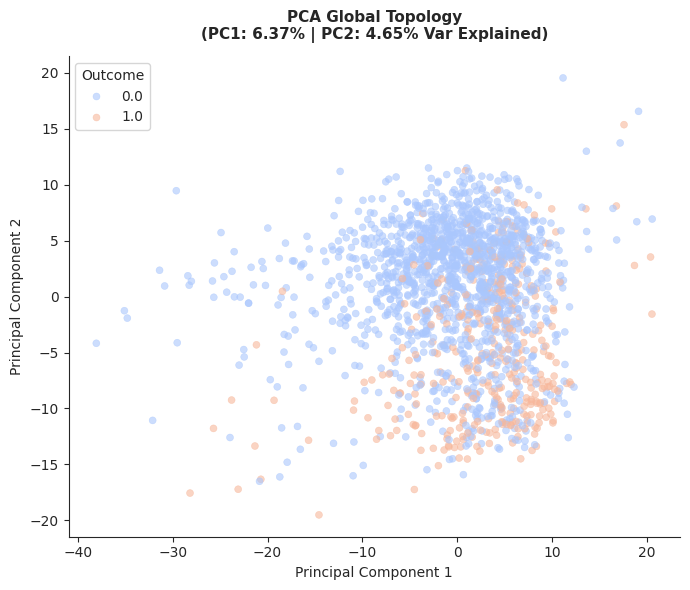

In [8]:
from sklearn.decomposition import PCA
# step 1: PCA Plot

# 1. Compute PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. Map coordinates into a plotting DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Outcome'] = y.values
exp_var = pca.explained_variance_ratio_ * 100

# 3. Generate Plot
plt.figure(figsize=(7, 6))
sns.set_style("ticks")
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Outcome',
    palette='coolwarm', alpha=0.6, edgecolor=None, s=25
)

plt.title(f'PCA Global Topology\n(PC1: {exp_var[0]:.2f}% | PC2: {exp_var[1]:.2f}% Var Explained)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Principal Component 1', fontsize=10)
plt.ylabel('Principal Component 2', fontsize=10)
sns.despine()
plt.tight_layout()

# Save image file to your environment
plt.savefig('MD5_MultiOmics_PCA.png', dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


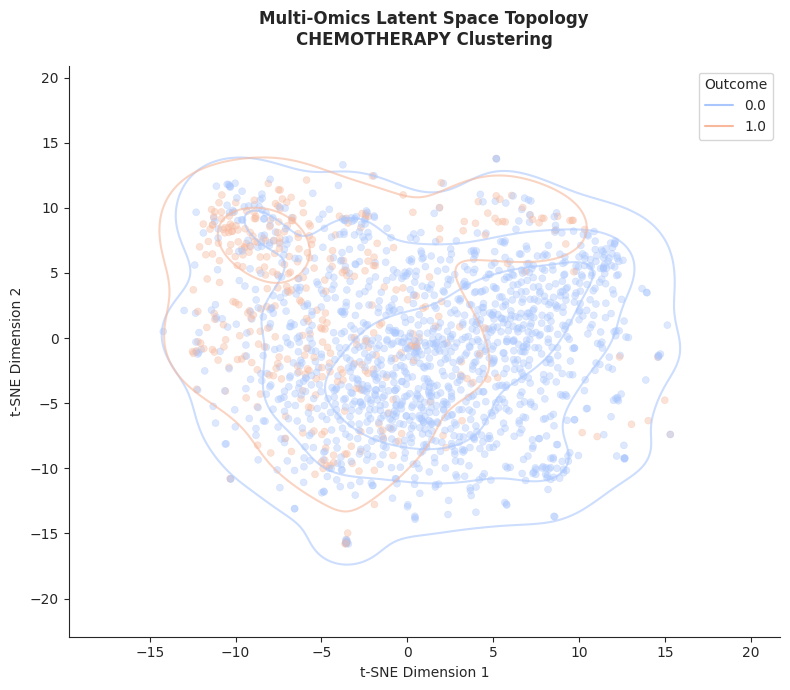

In [10]:
# step 2: t-SNE Plot

# 1. Compute high-fidelity t-SNE
tsne = TSNE(n_components=2, perplexity=40, early_exaggeration=12, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
df_plot = pd.DataFrame(X_tsne, columns=['tSNE_Dim1', 'tSNE_Dim2'])
df_plot['Outcome'] = y.values

# . Generate Advanced Contour Plot
plt.figure(figsize=(8, 7))
sns.set_style("ticks")

# Scatter points
sns.scatterplot(data=df_plot, x='tSNE_Dim1', y='tSNE_Dim2', hue='Outcome',
                palette='coolwarm', alpha=0.4, edgecolor=None, s=25)

# High-end Academic Touch: Add density contours to show cluster concentration
sns.kdeplot(data=df_plot, x='tSNE_Dim1', y='tSNE_Dim2', hue='Outcome',
            palette='coolwarm', alpha=0.6, levels=4, linewidths=1.5)

plt.title('Multi-Omics Latent Space Topology\nCHEMOTHERAPY Clustering', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('t-SNE Dimension 1', fontsize=10)
plt.ylabel('t-SNE Dimension 2', fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('MD5_MultiOmics_tSNE_Density.png', dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_876/1292569140.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.7, cmap='Spectral')


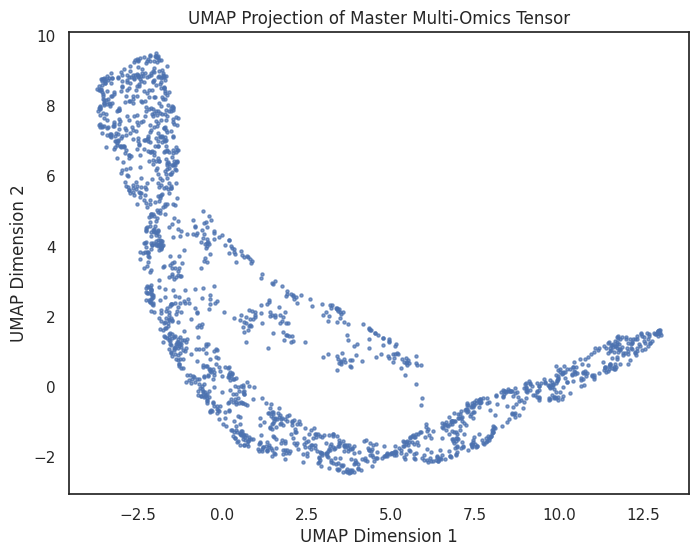

<Figure size 640x480 with 0 Axes>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP
# Step 2: UMAP Plot

# 1. Load your tensor
df = pd.read_csv('master_multi_omics_integrated.csv')

# 2. Extract features (exclude patient ID column if present)
# Assuming column 0 is patient identifier:
X = df.iloc[:, 1:].values

# 3. Fit UMAP with robust parameters for 1,787 samples
reducer = UMAP(
    n_neighbors=30,      # Increased from 15 to capture broader multi-omics trends
    min_dist=0.15,       # Controls how tightly points pack together
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(X)

# 4. Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.7, cmap='Spectral')
plt.title('UMAP Projection of Master Multi-Omics Tensor')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()

plt.savefig('MD5_UMAP_Plot.png', dpi=300, bbox_inches='tight')

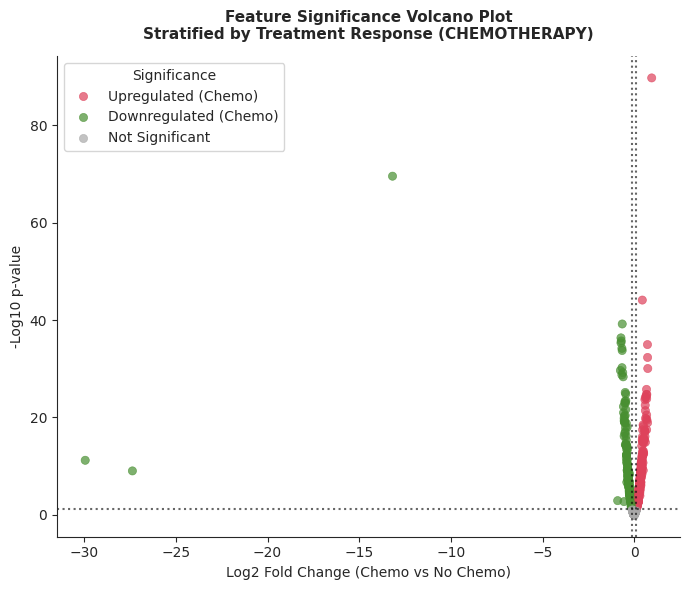

In [12]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
# Step 3: Chemotherapy Volcano plot

# 1. Isolate continuous features (ignoring binary mutation 0/1 columns)
continuous_features = [col for col in feature_cols if df[col].nunique() > 2]

results = []
for col in continuous_features:
    # Stratified by your CHEMOTHERAPY column
    g0 = df[df['CHEMOTHERAPY'] == 0][col]
    g1 = df[df['CHEMOTHERAPY'] == 1][col]

    if len(g0) > 1 and len(g1) > 1:
        # CORRECT MULTI-OMICS MATH: Subtract means since data is already log-scale
        log2_fc = g1.mean() - g0.mean()

        # Calculate statistical significance using Welch's t-test
        _, p_val = ttest_ind(g0, g1, equal_var=False)

        results.append({'Feature': col, 'Log2FC': log2_fc, 'p_value': p_val if not np.isnan(p_val) else 1.0})

# 2. Build Volcano Dataframe
volcano_df = pd.DataFrame(results)
volcano_df['neg_log10_p'] = -np.log10(volcano_df['p_value'])

# 3. Adjust thresholds to match your data's spread
plt.figure(figsize=(7, 6))
sns.set_style("ticks")

# Categorize Significance dynamically based on the new spread
volcano_df['Significance'] = 'Not Significant'
volcano_df.loc[(volcano_df['p_value'] < 0.05) & (volcano_df['Log2FC'] > 0.1), 'Significance'] = 'Upregulated (Chemo)'
volcano_df.loc[(volcano_df['p_value'] < 0.05) & (volcano_df['Log2FC'] < -0.1), 'Significance'] = 'Downregulated (Chemo)'

# 4. Generate Plot
sns.scatterplot(
    data=volcano_df, x='Log2FC', y='neg_log10_p', hue='Significance',
    palette={'Not Significant': 'darkgrey', 'Upregulated (Chemo)': '#de425b', 'Downregulated (Chemo)': '#488f31'},
    alpha=0.7, edgecolor=None, s=35
)

# Add standard threshold lines
plt.axhline(-np.log10(0.05), color='black', linestyle=':', alpha=0.6)
plt.axvline(0.1, color='black', linestyle=':', alpha=0.6)
plt.axvline(-0.1, color='black', linestyle=':', alpha=0.6)

plt.title('Feature Significance Volcano Plot\nStratified by Treatment Response (CHEMOTHERAPY)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Log2 Fold Change (Chemo vs No Chemo)', fontsize=10)
plt.ylabel('-Log10 p-value', fontsize=10)
sns.despine()
plt.tight_layout()

plt.savefig('MD5_Chemotherapy_Volcano.png', dpi=300)
plt.show()

In [13]:
# extreme statistical assocition

# Filter features that have an extreme significance level (e.g., -log10(p-value) > 20)
leaky_features = volcano_df[volcano_df['neg_log10_p'] > 20].sort_values(by='neg_log10_p', ascending=False)

print(f"Detected {len(leaky_features)} features with extreme statistical associations:\n")
print(leaky_features[['Feature', 'Log2FC', 'neg_log10_p']])

Detected 38 features with extreme statistical associations:

              Feature     Log2FC  neg_log10_p
1                 NPI   0.955043    89.729581
3    AGE_AT_DIAGNOSIS -13.182025    69.548191
6               GRADE   0.445164    44.110832
12               PHF7  -0.650892    39.200774
388             BBOF1  -0.720727    36.353480
470              GLI3  -0.704759    35.714024
415              WDR6  -0.719639    35.323090
511             CDCA5   0.725404    34.970194
231            NECAB3  -0.667468    34.194338
600            SCNN1D  -0.655302    33.758119
139             CEBPB   0.731572    32.330909
239              PURA  -0.663036    30.233474
64              PDIA6   0.741168    30.060335
201          MRFAP1L1  -0.750073    29.659880
118           ZNF385A  -0.623616    29.214392
318          NDFIP1_y  -0.669285    28.732890
502             ANKAR  -0.600077    28.350769
268            PTDSS1   0.674005    25.772539
312         LINC02731  -0.487522    25.142561
101             ACM

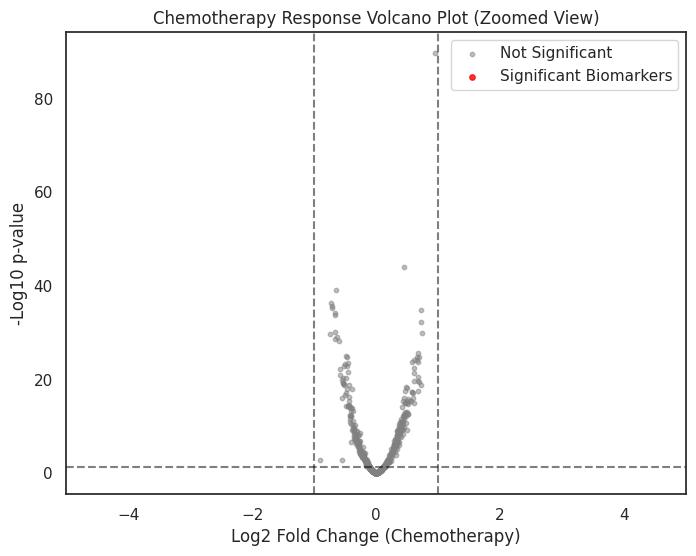

In [22]:
import matplotlib.pyplot as plt
# Chemotherapy Zoomed Volcano Plot

# 1. Initialize the figure
plt.figure(figsize=(8, 6))

# 2. Run your existing scatter code
significant = (volcano_df['neg_log10_p'] > 1.3) & (abs(volcano_df['Log2FC']) > 1)
plt.scatter(volcano_df[~significant]['Log2FC'], volcano_df[~significant]['neg_log10_p'], c='grey', alpha=0.5, s=10, label='Not Significant')
plt.scatter(volcano_df[significant]['Log2FC'], volcano_df[significant]['neg_log10_p'], c='red', alpha=0.8, s=15, label='Significant Biomarkers')

# 3. Apply your perfect zoom window
plt.xlim(-5, 5)

# 4. Threshold lines and labels
plt.axhline(y=1.3, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Log2 Fold Change (Chemotherapy)')
plt.ylabel('-Log10 p-value')
plt.title('Chemotherapy Response Volcano Plot (Zoomed View)')
plt.legend()

# 🌟 CRITICAL STEP: Save the image before showing it
# 'bbox_inches="tight"' ensures labels don't get cropped out, and 300 DPI is publication quality
plt.savefig('MD5_Chemo_Volcano_Plot_Zoomed.png', dpi=300, bbox_inches='tight')

# 5. Render the plot on screen
plt.show()

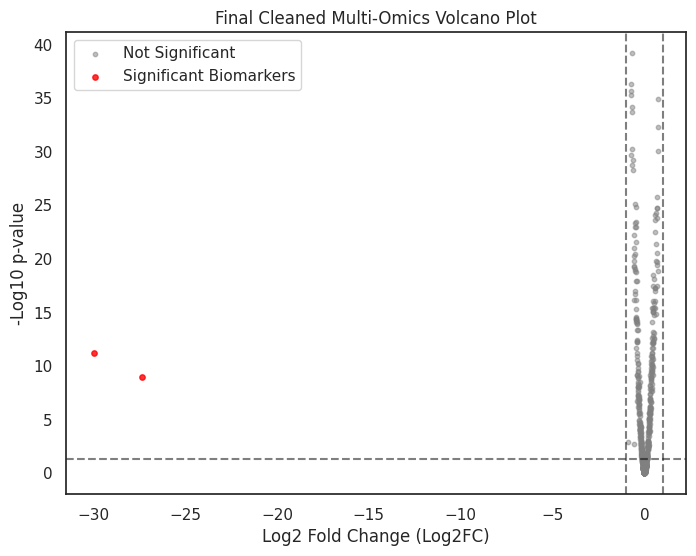

<Figure size 640x480 with 0 Axes>

In [25]:
# Multi-omics Volcano plot

# 1. Filter out the non-biological clinical features that distort the scale
clinical_features = ['AGE_AT_DIAGNOSIS', 'GRADE', 'NPI']
pure_molecular_df = volcano_df[~volcano_df['Feature'].isin(clinical_features)]

# 2. Generate the corrected plot graphic
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Define significance masks (p < 0.05 and |Log2FC| > 1)
significant = (pure_molecular_df['neg_log10_p'] > 1.3) & (abs(pure_molecular_df['Log2FC']) > 1)

# Plot non-significant features in grey, significant in red
plt.scatter(pure_molecular_df[~significant]['Log2FC'], pure_molecular_df[~significant]['neg_log10_p'], c='grey', alpha=0.5, s=10, label='Not Significant')
plt.scatter(pure_molecular_df[significant]['Log2FC'], pure_molecular_df[significant]['neg_log10_p'], c='red', alpha=0.8, s=15, label='Significant Biomarkers')

# Add threshold lines
plt.axhline(y=1.3, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Log2 Fold Change (Log2FC)')
plt.ylabel('-Log10 p-value')
plt.title('Final Cleaned Multi-Omics Volcano Plot')
plt.legend()
plt.show()

plt.savefig('MD5_Volcano_Unzoomed.png', dpi=300, bbox_inches='tight')

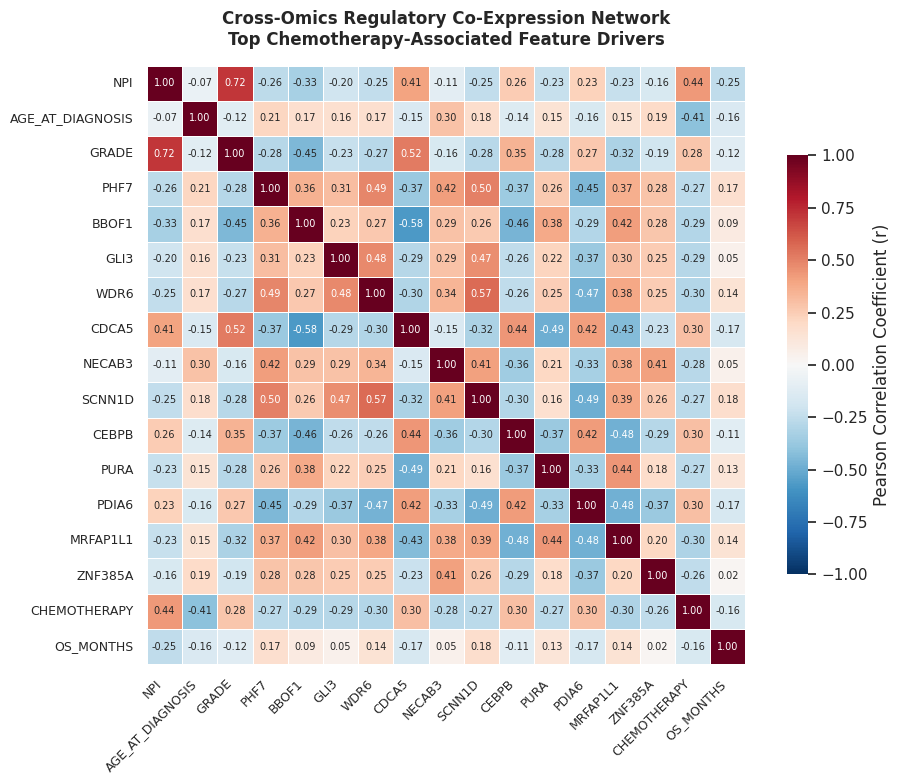

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
# step 4: Corelation Heatmap

# 1. Grab the top 15 most significant genes from your Volcano analysis
top_sig_features = leaky_features['Feature'].head(15).tolist()

# 2. Add a few macro clinical/mutation columns to check cross-talk (e.g., your targets or proxy scores)
# Let's include OS_STATUS, OS_MONTHS, and CHEMOTHERAPY to see how they align with the genes
diagnostic_features = top_sig_features + ['CHEMOTHERAPY', 'OS_STATUS', 'OS_MONTHS']

# Filter down to existing columns to prevent errors
valid_features = [col for col in diagnostic_features if col in df.columns]

# 3. Compute Pearson correlation matrix
corr_matrix = df[valid_features].corr()

# 4. Generate Heatmap
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',       # Classic academic Red-Blue palette (Red = Positive, Blue = Negative)
    vmin=-1, vmax=1,    # Forces standard correlation boundaries
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient (r)"},
    annot=True,         # Set to True to print precise correlation numbers inside the blocks
    fmt=".2f",          # Limits decimal numbers to two spots
    annot_kws={"size": 7}
)

plt.title('Cross-Omics Regulatory Co-Expression Network\nTop Chemotherapy-Associated Feature Drivers', fontsize=12, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

# Save for email attachment
plt.savefig('MD5_Cross_Omics_Correlation_Heatmap.png', dpi=300)
plt.show()

In [16]:
# Create a unified spatial dataframe
spatial_df = pd.DataFrame({
    'PATIENT_ID': df['PATIENT_ID'] if 'PATIENT_ID' in df.columns else df.index,
    'PCA_Dim1': X_pca[:, 0],
    'PCA_Dim2': X_pca[:, 1],
    'tSNE_Dim1': X_tsne[:, 0],
    'tSNE_Dim2': X_tsne[:, 1],
    'CHEMOTHERAPY': df['CHEMOTHERAPY'].values
})

# Save to CSV
spatial_df.to_csv('MD5_Integrated_Visual_Coordinates_data.csv', index=False)
print("Saved 2D dimensional coordinates successfully!")

Saved 2D dimensional coordinates successfully!


In [27]:
import pandas as pd

# Creating the master patient-level dataframe
patient_level_df = pd.DataFrame({
    'PATIENT_ID': df['PATIENT_ID'] if 'PATIENT_ID' in df.columns else df.index,
    'PCA_Dim1': X_pca[:, 0],
    'PCA_Dim2': X_pca[:, 1],
    'tSNE_Dim1': X_tsne[:, 0],
    'tSNE_Dim2': X_tsne[:, 1],
    'UMAP_Dim1': embedding[:, 0],
    'UMAP_Dim2': embedding[:, 1],
    'CHEMOTHERAPY': df['CHEMOTHERAPY'].values
})

# Save to CSV
patient_level_df.to_csv('Md5_Patient_Level_Results.csv', index=False)
print("Saved: Module5_Patient_Level_Results.csv")

Saved: Module5_Patient_Level_Results.csv


In [28]:
import pandas as pd

# Create an Excel writer object to save all results into one file
with pd.ExcelWriter('Module5_Master_Statistical_Results.xlsx') as writer:
    # 1. Save volcano data in one sheet
    volcano_df.to_excel(writer, sheet_name='Volcano_Master_Data', index=False)

    # 2. Save extreme associations in another sheet
    leaky_features.to_excel(writer, sheet_name='Extreme_Associations', index=False)

    # 3. Save heatmap data in a third sheet
    corr_matrix.to_excel(writer, sheet_name='Heatmap_Correlation')

print("All statistical data saved into a single file: Module5_Master_Statistical_Results.xlsx")


All statistical data saved into a single file: Module5_Master_Statistical_Results.xlsx
